In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from diffusion_solvers import two_group_setup, inverse_power_block, create_grid

In [2]:
D = lambda r, g: 1.2*(g==0) + 0.4*(g==1 and r<=180) + 0.2*(g==1 and r>180)
def Sig_r(r, g):
    if g == 0:
        if 20<r<=180:
            value = 0.02965
        elif r<=20:
            value = 0.02982
        elif r>180:
            value = 0.051
    elif g==1:
        if r<=20:
            value = 0.09848
        elif r>180:
            value = 0.04
        elif 20<r<=40 or 60<r<=80 or 100<r<=120 or 140<r<=160:
            value = 0.23633
        elif 40<r<=60 or 80<r<=100 or 120<r<=140 or 160<r<=180:
            value = 0.09308
    return value
def nuSig_f(r, g):
    if g==0:
        if r<=20 or 40<r<=60 or 80<r<=100 or 120<r<=140 or 160<r<=180:
            value = 0.00457
        elif 20<r<=40 or 60<r<=80 or 100<r<=120 or 140<r<=160:
            value = 0.00685
        else:
            value = 0
    elif g==1:
        if r<=20 or 40<r<=60 or 80<r<=100 or 120<r<=140 or 160<r<=180:
            value = 0.1142
        elif 20<r<=40 or 60<r<=80 or 100<r<=120 or 140<r<=160:
            value = 0.3519
        else:
            value = 0
    return value
def Sig_s(r):
    if r<=20 or 40<r<=60 or 80<r<=100 or 120<r<=140 or 160<r<=180:
        value = 0.02043
    elif 20<r<=40 or 60<r<=80 or 100<r<=120 or 140<r<=160:
        value = 0.01587
    elif r>180:
        value = 0.05
    return value

keff (rodded) = 1.1108069576848927
keff (un-rodded) = 1.1119183672827944


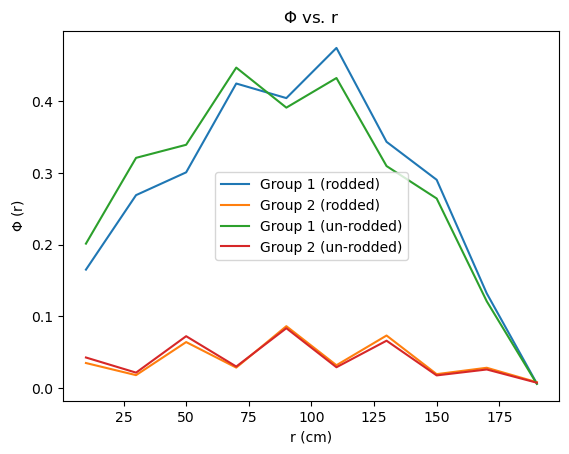

In [7]:
R = 200
I = 10
BC = [0, 1, 0]
Delta_r, centers, edges = create_grid(R,I)
result = two_group_setup(R, 2, I, D, Sig_r, nuSig_f, Sig_s, BC, geometry=1)
# for matrix in result:
#     dict = {}
#     for i in range(I+1):
#         dict.update({f"C{i}": matrix[:,i]})
#     df = pd.DataFrame(dict)
#     display(df)
M11, M21, M22, P11, P12 = two_group_setup(R, 2, I, D, Sig_r, nuSig_f, Sig_s, BC, geometry=1)
k, phi1, phi2 = inverse_power_block(M11, M21, M22, P11, P12)
print(f"keff (rodded) = {k}")

plt.plot(centers, phi1[:-1], label="Group 1 (rodded)")
plt.plot(centers, phi2[:-1], label="Group 2 (rodded)")
plt.ylabel("$\\Phi$ (r)")
plt.xlabel("r (cm)")
plt.title("$\\Phi$ vs. r")
D = lambda r, g: 1.2*(g==0) + 0.4*(g==1 and r<=180) + 0.2*(g==1 and r>180)
def Sig_r(r, g):
    if g == 0:
        if 20<r<=180:
            value = 0.02965
        elif r<=20:
            value = 0.02965 # U now
        elif r>180:
            value = 0.051
    elif g==1:
        if r<=20:
            value = 0.09308 # U now
        elif r>180:
            value = 0.04
        elif 20<r<=40 or 60<r<=80 or 100<r<=120 or 140<r<=160:
            value = 0.23633
        elif 40<r<=60 or 80<r<=100 or 120<r<=140 or 160<r<=180:
            value = 0.09308
    return value
def nuSig_f(r, g): # U already equals U rodded
    if g==0:
        if r<=20 or 40<r<=60 or 80<r<=100 or 120<r<=140 or 160<r<=180:
            value = 0.00457
        elif 20<r<=40 or 60<r<=80 or 100<r<=120 or 140<r<=160:
            value = 0.00685
        else:
            value = 0
    elif g==1:
        if r<=20 or 40<r<=60 or 80<r<=100 or 120<r<=140 or 160<r<=180:
            value = 0.1142
        elif 20<r<=40 or 60<r<=80 or 100<r<=120 or 140<r<=160:
            value = 0.3519
        else:
            value = 0
    return value
def Sig_s(r): # U already equals U rodded
    if r<=20 or 40<r<=60 or 80<r<=100 or 120<r<=140 or 160<r<=180:
        value = 0.02043
    elif 20<r<=40 or 60<r<=80 or 100<r<=120 or 140<r<=160:
        value = 0.01587
    elif r>180:
        value = 0.05
    return value
result = two_group_setup(R, 2, I, D, Sig_r, nuSig_f, Sig_s, BC, geometry=1)
# for matrix in result:
#     dict = {}
#     for i in range(I+1):
#         dict.update({f"C{i}": matrix[:,i]})
#     df = pd.DataFrame(dict)
#     display(df)
M11, M21, M22, P11, P12 = two_group_setup(R, 2, I, D, Sig_r, nuSig_f, Sig_s, BC, geometry=1)
k, phi1, phi2 = inverse_power_block(M11, M21, M22, P11, P12)
print(f"keff (un-rodded) = {k}")

plt.plot(centers, phi1[:-1], label="Group 1 (un-rodded)")
plt.plot(centers, phi2[:-1], label="Group 2 (un-rodded)")
plt.legend()
plt.show()